<a href="https://colab.research.google.com/github/sumandash509/AML_LAB/blob/main/AMLLAB05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ridge regression using gradient descent technique to solve



Enter the X feature: 1,2,3,4
Enter the Y feature: 5,6,7,8
Weight (w): 1.9294
Bias (b): 1.1283


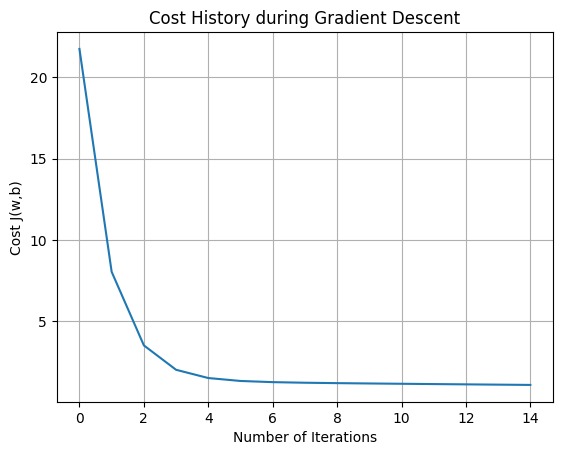

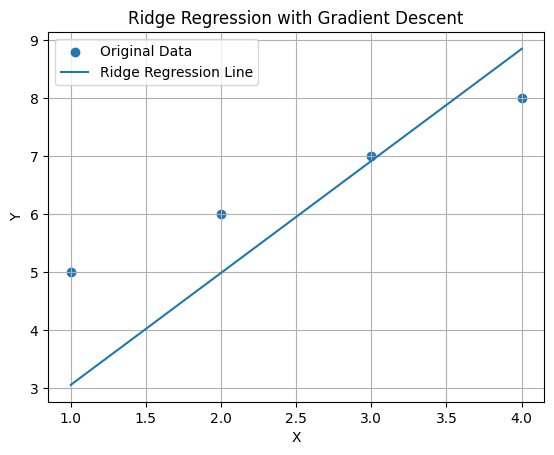

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def ridge_regression_1d(x, y, learning_rate, iterations, lam):
    w = 0.0
    b = 0.0
    cost_history = []

    n = len(y)

    for i in range(iterations):
        # Prediction
        y_pred = w * x + b

        # Cost function
        cost = (1 / (2 * n)) * np.sum((y_pred - y) ** 2) + (lam / 2) * (w ** 2)
        cost_history.append(cost)

        # Gradients
        dw = (1 / n) * np.sum((y_pred - y) * x) + lam * w
        db = (1 / n) * np.sum(y_pred - y)

        # Parameter update
        w -= learning_rate * dw
        b -= learning_rate * db

    return w, b, cost_history


# Input data
x_input = input("Enter the X feature: ")
y_input = input("Enter the Y feature: ")

x = np.array([float(val) for val in x_input.split(",")])
y = np.array([float(val) for val in y_input.split(",")])

learning_rate = 0.05
n_iter = 15
lam = 0.2

# Run Ridge Regression
w, b, cost_history = ridge_regression_1d(
    x, y, learning_rate, n_iter, lam
)

print(f"Weight (w): {w:.4f}")
print(f"Bias (b): {b:.4f}")


# Cost history plot
plt.plot(range(n_iter), cost_history)
plt.xlabel("Number of Iterations")
plt.ylabel("Cost J(w,b)")
plt.title("Cost History during Gradient Descent")
plt.grid(True)
plt.show()


# Ridge regression line
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_pred = w * x_sorted + b

plt.scatter(x, y, label="Original Data")
plt.plot(x_sorted, y_pred, label="Ridge Regression Line")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Ridge Regression with Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()

lasso


Enter x1 values: 1,-1,1,1
Enter x2 values: 1,1,-1,1
Enter y values: 2,-1,8,2
Final Parameters -> w1: 1.6304, w2: -1.1765, b: 1.9700


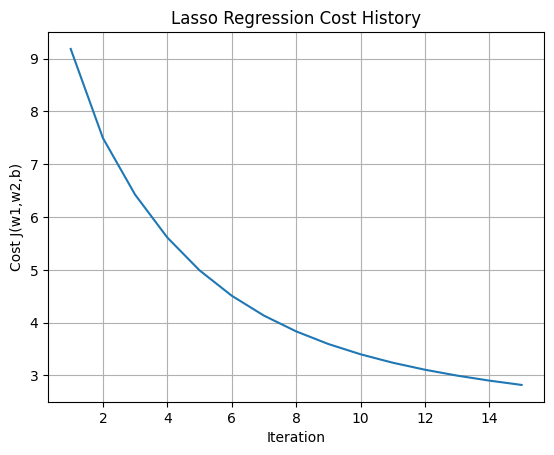

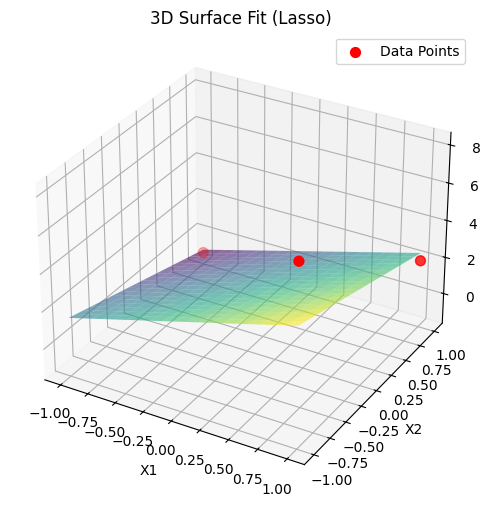

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def lasso_regression_2d(x1, x2, y, learning_rate, iterations, lam):
    w1 = 0.0
    w2 = 0.033
    b = 0.0

    cost_history = []
    n = len(y)

    for i in range(iterations):

        # Prediction
        y_pred = w1 * x1 + w2 * x2 + b

        # Cost function
        cost = (
            (1 / (2 * n)) * np.sum((y_pred - y) ** 2)
            + lam * (np.abs(w1) + np.abs(w2))
        )

        cost_history.append(cost)

        # Gradients
        dw1 = (
            (1 / n) * np.sum((y_pred - y) * x1)
            + lam * np.sign(w1)
        )

        dw2 = (
            (1 / n) * np.sum((y_pred - y) * x2)
            + lam * np.sign(w2)
        )

        db = (1 / n) * np.sum(y_pred - y)

        # Parameter update
        w1 -= learning_rate * dw1
        w2 -= learning_rate * dw2
        b -= learning_rate * db

    return w1, w2, b, cost_history


# Input values
x1_input = input("Enter x1 values: ")
x2_input = input("Enter x2 values: ")
y_input = input("Enter y values: ")

x1 = np.array([float(v) for v in x1_input.split(",")])
x2 = np.array([float(v) for v in x2_input.split(",")])
y = np.array([float(v) for v in y_input.split(",")])

learning_rate = 0.1
iterations = 15
lam = 0.5

# Run Lasso Regression
w1, w2, b, cost_history = lasso_regression_2d(
    x1, x2, y, learning_rate, iterations, lam
)

print(
    f"Final Parameters -> "
    f"w1: {w1:.4f}, w2: {w2:.4f}, b: {b:.4f}"
)


# Cost history plot
plt.figure()
plt.plot(range(1, iterations + 1), cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w1,w2,b)")
plt.title("Lasso Regression Cost History")
plt.grid(True)
plt.show()


# 3D surface plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# Original data points
ax.scatter(
    x1,
    x2,
    y,
    color="red",
    s=50,
    label="Data Points"
)

# Create grid
x1_grid = np.linspace(min(x1), max(x1), 20)
x2_grid = np.linspace(min(x2), max(x2), 20)

x1_mesh, x2_mesh = np.meshgrid(x1_grid, x2_grid)

# Predicted surface
y_surface = w1 * x1_mesh + w2 * x2_mesh + b

ax.plot_surface(
    x1_mesh,
    x2_mesh,
    y_surface,
    alpha=0.6,
    cmap="viridis"
)

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Y")
ax.set_title("3D Surface Fit (Lasso)")
ax.legend()

plt.show()